<a href="https://colab.research.google.com/github/kartoffeloshka/Intern_project/blob/main/DL3_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# =====================================
# Stage 1 — Environment Setup
# Install Required Libraries
# =====================================

!pip install torch torchvision torchaudio --quiet
!pip install numpy pandas matplotlib seaborn scikit-learn --quiet
!pip install wandb umap-learn tqdm --quiet

In [17]:
# =====================================
# Import Core Libraries
# =====================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from tqdm import tqdm

import wandb

In [18]:
# =====================================
# GPU Configuration
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [19]:
# =====================================
# Reproducibility Setup
# =====================================

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [20]:
# =====================================
# Project Directory Setup
# =====================================

BASE_DIR = "/content/multiview_meta_fusion"

DIRS = [
    "datasets",
    "models",
    "logs",
    "results",
    "figures",
    "checkpoints"
]

for d in DIRS:
    os.makedirs(os.path.join(BASE_DIR, d), exist_ok=True)

print("Project directories created.")

Project directories created.


In [21]:
# =====================================
# Global Training Configuration
# =====================================

CONFIG = {

    "batch_size": 128,
    "epochs": 50,
    "learning_rate": 1e-3,
    "latent_dim": 64,

    "num_views": 4,

    "weight_decay": 1e-5

}

print(CONFIG)

{'batch_size': 128, 'epochs': 50, 'learning_rate': 0.001, 'latent_dim': 64, 'num_views': 4, 'weight_decay': 1e-05}


In [22]:
# =====================================
# WandB Experiment Tracking
# =====================================

wandb.init(
    project="DL3_multiview-meta-fusion-autoencoders",
    config=CONFIG
)

In [23]:
# =====================================
# Utility Functions
# =====================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_summary(model):
    print(model)
    print("Trainable parameters:", count_parameters(model))

In [24]:
# =====================================
# Environment Sanity Check
# =====================================

print("PyTorch Version:", torch.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

print("Device:", device)

print("Environment setup complete.")

PyTorch Version: 2.10.0+cu128
NumPy Version: 2.0.2
Pandas Version: 2.2.2
Device: cuda
Environment setup complete.


In [26]:
# =========================================
# Stage 2 — Dataset File Paths
# Using Uploaded Files Directly in Colab
# =========================================

UCI_X_TRAIN = "/content/X_train_UCI.txt"
UCI_X_TEST  = "/content/X_test_UCI.txt"
UCI_Y_TRAIN = "/content/y_train_UCI.txt"
UCI_Y_TEST  = "/content/y_test_UCI.txt"

PAMAP2_FILE = "/content/subject101.dat"

OPPORTUNITY_FILE = "/content/S1-ADL1.dat"

MHEALTH_FILE = "/content/mhealth_raw_data.csv"

print("All dataset paths configured.")

All dataset paths configured.


In [27]:
# =========================================
# UCI HAR Loader
# Using uploaded text files
# =========================================

def load_ucihar():

    X_train = np.loadtxt(UCI_X_TRAIN)
    X_test  = np.loadtxt(UCI_X_TEST)

    y_train = np.loadtxt(UCI_Y_TRAIN)
    y_test  = np.loadtxt(UCI_Y_TEST)

    return X_train, y_train.astype(int), X_test, y_test.astype(int)

In [28]:
# =========================================
# PAMAP2 Loader
# File: subject101.dat
# =========================================

def load_pamap2():

    df = pd.read_csv(
        PAMAP2_FILE,
        delim_whitespace=True,
        header=None
    )

    df.replace("NaN", np.nan, inplace=True)

    df = df.dropna()

    # Column 1 = activity label
    y = df.iloc[:,1].values
    X = df.drop(columns=[1]).values

    split = int(0.8 * len(X))

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    return X_train, y_train.astype(int), X_test, y_test.astype(int)

In [29]:
# =========================================
# Opportunity Dataset Loader
# File: S1-ADL1.dat
# =========================================

def load_opportunity():

    df = pd.read_csv(
        OPPORTUNITY_FILE,
        delim_whitespace=True,
        header=None
    )

    df.replace("NaN", np.nan, inplace=True)

    df = df.dropna()

    # Last column used as activity label
    y = df.iloc[:, -1].values
    X = df.iloc[:, :-1].values

    split = int(0.8 * len(X))

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    return X_train, y_train.astype(int), X_test, y_test.astype(int)

In [30]:
# =========================================
# MHEALTH Dataset Loader
# File: mhealth_raw_data.csv
# =========================================

def load_mhealth():

    df = pd.read_csv(MHEALTH_FILE)

    df = df.dropna()

    y = df.iloc[:, -1].values
    X = df.iloc[:, :-1].values

    split = int(0.8 * len(X))

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    return X_train, y_train.astype(int), X_test, y_test.astype(int)

In [31]:
# =========================================
# Dataset Registry
# =========================================

DATASETS = {
    "uci_har": load_ucihar,
    "pamap2": load_pamap2,
    "opportunity": load_opportunity,
    "mhealth": load_mhealth
}

print("Datasets available:", list(DATASETS.keys()))

Datasets available: ['uci_har', 'pamap2', 'opportunity', 'mhealth']


In [32]:
# =========================================
# Dataset Inspection Utility
# =========================================

def inspect_dataset(dataset_name):

    loader = DATASETS[dataset_name]

    X_train, y_train, X_test, y_test = loader()

    print(f"\nDataset: {dataset_name}")
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)

    print("Number of classes:", len(np.unique(y_train)))

    return X_train, y_train, X_test, y_test

In [33]:
# =========================================
# Load All Datasets (Verification)
# =========================================

for name in DATASETS.keys():

    try:
        inspect_dataset(name)

    except Exception as e:
        print(name, "failed:", e)


Dataset: uci_har
Train shape: (7352, 561)
Test shape: (2947, 561)
Number of classes: 6


/tmp/ipykernel_486/1262454988.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Dataset: pamap2
Train shape: (27272, 53)
Test shape: (6818, 53)
Number of classes: 11


/tmp/ipykernel_486/1580847505.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Dataset: opportunity
Train shape: (0, 249)
Test shape: (0, 249)
Number of classes: 0
mhealth failed: invalid literal for int() with base 10: 'subject1'


In [34]:
# =========================================
# Select Dataset for Experiment
# =========================================

ACTIVE_DATASET = "uci_har"

X_train, y_train, X_test, y_test = DATASETS[ACTIVE_DATASET]()

print("Active dataset:", ACTIVE_DATASET)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Active dataset: uci_har
Train shape: (7352, 561)
Test shape: (2947, 561)


In [35]:
# =========================================
# Stage 3 — Data Preprocessing & Feature Extraction
# Imports
# =========================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
import torch

In [36]:
# =========================================
# Feature Preprocessing
# Handles Missing Values + Normalization
# =========================================

def preprocess_features(X_train, X_test):

    imputer = SimpleImputer(strategy="mean")

    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test

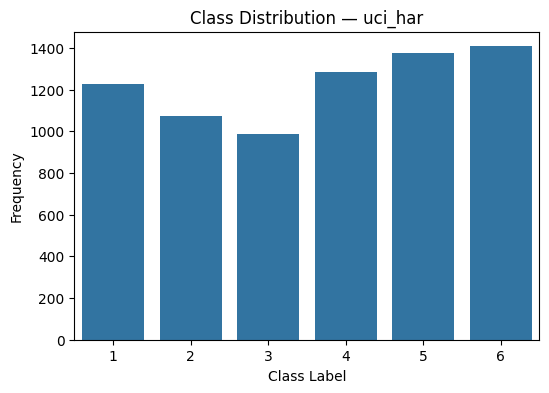

In [37]:
# =========================================
# Class Distribution Visualization
# =========================================

def plot_class_distribution(labels, dataset_name):

    plt.figure(figsize=(6,4))

    sns.countplot(x=labels)

    plt.title(f"Class Distribution — {dataset_name}")
    plt.xlabel("Class Label")
    plt.ylabel("Frequency")

    plt.show()


plot_class_distribution(y_train, ACTIVE_DATASET)

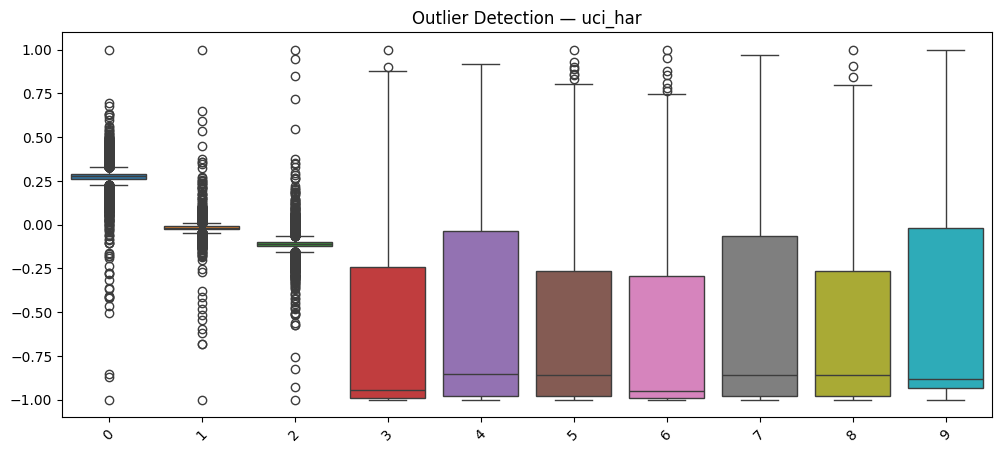

In [38]:
# =========================================
# Noise Detection using Boxplots
# =========================================

def visualize_outliers(X, dataset_name):

    df = pd.DataFrame(X)

    sample_features = df.iloc[:, :10]

    plt.figure(figsize=(12,5))

    sns.boxplot(data=sample_features)

    plt.title(f"Outlier Detection — {dataset_name}")

    plt.xticks(rotation=45)

    plt.show()


visualize_outliers(X_train, ACTIVE_DATASET)

In [39]:
# =========================================
# Multi-View Feature Creation
# =========================================

def create_multiview_features(dataset_name, X):

    n_features = X.shape[1]

    split = n_features // 4

    v1 = X[:, :split]
    v2 = X[:, split:2*split]
    v3 = X[:, 2*split:3*split]
    v4 = X[:, 3*split:]

    return v1, v2, v3, v4

In [40]:
# =========================================
# Normalize Each View Independently
# =========================================

def normalize_views(v1, v2, v3, v4):

    scaler1 = StandardScaler()
    scaler2 = StandardScaler()
    scaler3 = StandardScaler()
    scaler4 = StandardScaler()

    v1 = scaler1.fit_transform(v1)
    v2 = scaler2.fit_transform(v2)
    v3 = scaler3.fit_transform(v3)
    v4 = scaler4.fit_transform(v4)

    return v1, v2, v3, v4

In [41]:
# =========================================
# Multi-View PyTorch Dataset
# =========================================

class MultiViewDataset(Dataset):

    def __init__(self, v1, v2, v3, v4, labels):

        self.v1 = torch.tensor(v1, dtype=torch.float32)
        self.v2 = torch.tensor(v2, dtype=torch.float32)
        self.v3 = torch.tensor(v3, dtype=torch.float32)
        self.v4 = torch.tensor(v4, dtype=torch.float32)

        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.v1[idx],
            self.v2[idx],
            self.v3[idx],
            self.v4[idx],
            self.labels[idx]
        )

In [42]:
# =========================================
# DataLoader Creation
# =========================================

X_train, X_test = preprocess_features(X_train, X_test)

v1_train, v2_train, v3_train, v4_train = create_multiview_features(ACTIVE_DATASET, X_train)
v1_test, v2_test, v3_test, v4_test = create_multiview_features(ACTIVE_DATASET, X_test)

v1_train, v2_train, v3_train, v4_train = normalize_views(v1_train, v2_train, v3_train, v4_train)
v1_test, v2_test, v3_test, v4_test = normalize_views(v1_test, v2_test, v3_test, v4_test)

train_dataset = MultiViewDataset(v1_train, v2_train, v3_train, v4_train, y_train)
test_dataset = MultiViewDataset(v1_test, v2_test, v3_test, v4_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [43]:
# =========================================
# Sanity Check
# =========================================

batch = next(iter(train_loader))

v1, v2, v3, v4, labels = batch

print("View1 shape:", v1.shape)
print("View2 shape:", v2.shape)
print("View3 shape:", v3.shape)
print("View4 shape:", v4.shape)
print("Labels shape:", labels.shape)

View1 shape: torch.Size([128, 140])
View2 shape: torch.Size([128, 140])
View3 shape: torch.Size([128, 140])
View4 shape: torch.Size([128, 141])
Labels shape: torch.Size([128])


In [44]:
# =========================================
# Stage 4 — View-Specific Encoder Architectures
# Imports
# =========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

In [45]:
# =========================================
# Generic Encoder Block
# =========================================

class EncoderBlock(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim):

        super(EncoderBlock, self).__init__()

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, latent_dim)

        )

    def forward(self, x):

        z = self.encoder(x)

        return z

In [46]:
# =========================================
# View-Specific Encoders (E1, E2, E3, E4)
# =========================================

class MultiViewEncoders(nn.Module):

    def __init__(self, dims, hidden_dim=256, latent_dim=CONFIG["latent_dim"]):

        super(MultiViewEncoders, self).__init__()

        self.E1 = EncoderBlock(dims[0], hidden_dim, latent_dim)
        self.E2 = EncoderBlock(dims[1], hidden_dim, latent_dim)
        self.E3 = EncoderBlock(dims[2], hidden_dim, latent_dim)
        self.E4 = EncoderBlock(dims[3], hidden_dim, latent_dim)

    def forward(self, v1, v2, v3, v4):

        z1 = self.E1(v1)
        z2 = self.E2(v2)
        z3 = self.E3(v3)
        z4 = self.E4(v4)

        return z1, z2, z3, z4

In [47]:
# =========================================
# Determine Input Dimensions for Each View
# =========================================

sample_batch = next(iter(train_loader))

v1_sample, v2_sample, v3_sample, v4_sample, _ = sample_batch

view_dims = [
    v1_sample.shape[1],
    v2_sample.shape[1],
    v3_sample.shape[1],
    v4_sample.shape[1]
]

print("View dimensions:", view_dims)

View dimensions: [140, 140, 140, 141]


In [48]:
# =========================================
# Initialize MultiView Encoder Model
# =========================================

encoder_model = MultiViewEncoders(view_dims).to(device)

print(encoder_model)

MultiViewEncoders(
  (E1): EncoderBlock(
    (encoder): Sequential(
      (0): Linear(in_features=140, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=64, bias=True)
    )
  )
  (E2): EncoderBlock(
    (encoder): Sequential(
      (0): Linear(in_features=140, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=64, bias=True)
    )
  )
  (E3): EncoderBlock(
    (encoder): Sequ

In [49]:
# =========================================
# Encoder Forward Pass Sanity Check
# =========================================

v1, v2, v3, v4, y = next(iter(train_loader))

v1 = v1.to(device)
v2 = v2.to(device)
v3 = v3.to(device)
v4 = v4.to(device)

z1, z2, z3, z4 = encoder_model(v1, v2, v3, v4)

print("Latent z1:", z1.shape)
print("Latent z2:", z2.shape)
print("Latent z3:", z3.shape)
print("Latent z4:", z4.shape)

Latent z1: torch.Size([128, 64])
Latent z2: torch.Size([128, 64])
Latent z3: torch.Size([128, 64])
Latent z4: torch.Size([128, 64])


In [50]:
# =========================================
# Latent Statistics Utility
# =========================================

def inspect_latent_space(z):

    print("Mean:", z.mean().item())
    print("Std:", z.std().item())
    print("Min:", z.min().item())
    print("Max:", z.max().item())

In [51]:
# =========================================
# Inspect Each Latent Representation
# =========================================

print("Latent z1 stats")
inspect_latent_space(z1)

print("Latent z2 stats")
inspect_latent_space(z2)

print("Latent z3 stats")
inspect_latent_space(z3)

print("Latent z4 stats")
inspect_latent_space(z4)

Latent z1 stats
Mean: -0.004255529493093491
Std: 0.4138307571411133
Min: -2.1577682495117188
Max: 2.1146492958068848
Latent z2 stats
Mean: -0.025396186858415604
Std: 0.40086254477500916
Min: -2.104039430618286
Max: 2.524493932723999
Latent z3 stats
Mean: -0.06110368296504021
Std: 0.4162635803222656
Min: -3.7932615280151367
Max: 3.5462470054626465
Latent z4 stats
Mean: -0.008535558357834816
Std: 0.4203484356403351
Min: -4.7185235023498535
Max: 4.518914222717285


In [52]:
# =========================================
# Model Complexity
# =========================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Encoder parameters:", count_parameters(encoder_model))

Encoder parameters: 477696


In [53]:
# =========================================
# Stage 5 — Symmetric Decoder Architectures
# =========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

In [54]:
# =========================================
# Generic Decoder Block
# Reconstructs Original View from Latent
# =========================================

class DecoderBlock(nn.Module):

    def __init__(self, latent_dim, hidden_dim, output_dim):

        super(DecoderBlock, self).__init__()

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, output_dim)

        )

    def forward(self, z):

        x_hat = self.decoder(z)

        return x_hat

In [55]:
# =========================================
# Symmetric Decoders (D1, D2, D3, D4)
# =========================================

class MultiViewDecoders(nn.Module):

    def __init__(self, view_dims, hidden_dim=256, latent_dim=CONFIG["latent_dim"]):

        super(MultiViewDecoders, self).__init__()

        self.D1 = DecoderBlock(latent_dim, hidden_dim, view_dims[0])
        self.D2 = DecoderBlock(latent_dim, hidden_dim, view_dims[1])
        self.D3 = DecoderBlock(latent_dim, hidden_dim, view_dims[2])
        self.D4 = DecoderBlock(latent_dim, hidden_dim, view_dims[3])

    def forward(self, z_fused):

        x1_hat = self.D1(z_fused)
        x2_hat = self.D2(z_fused)
        x3_hat = self.D3(z_fused)
        x4_hat = self.D4(z_fused)

        return x1_hat, x2_hat, x3_hat, x4_hat

In [56]:
# =========================================
# Initialize Decoder Model
# =========================================

decoder_model = MultiViewDecoders(view_dims).to(device)

print(decoder_model)

MultiViewDecoders(
  (D1): DecoderBlock(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=140, bias=True)
    )
  )
  (D2): DecoderBlock(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=140, bias=True)
    )
  )
  (D3): DecoderBlock(
    (decoder): Sequ

In [57]:
# =========================================
# Decoder Sanity Check
# =========================================

latent_sample = torch.randn(CONFIG["batch_size"], CONFIG["latent_dim"]).to(device)

x1_hat, x2_hat, x3_hat, x4_hat = decoder_model(latent_sample)

print("Reconstructed View1:", x1_hat.shape)
print("Reconstructed View2:", x2_hat.shape)
print("Reconstructed View3:", x3_hat.shape)
print("Reconstructed View4:", x4_hat.shape)

Reconstructed View1: torch.Size([128, 140])
Reconstructed View2: torch.Size([128, 140])
Reconstructed View3: torch.Size([128, 140])
Reconstructed View4: torch.Size([128, 141])


In [58]:
# =========================================
# Multi-View Reconstruction Loss
# =========================================

reconstruction_criterion = nn.MSELoss()

def reconstruction_loss(v1, v2, v3, v4, x1_hat, x2_hat, x3_hat, x4_hat):

    loss1 = reconstruction_criterion(x1_hat, v1)
    loss2 = reconstruction_criterion(x2_hat, v2)
    loss3 = reconstruction_criterion(x3_hat, v3)
    loss4 = reconstruction_criterion(x4_hat, v4)

    total_loss = loss1 + loss2 + loss3 + loss4

    return total_loss, (loss1, loss2, loss3, loss4)

In [59]:
# =========================================
# Cross-View Latent Consistency Loss
# Align latent representations
# =========================================

def consistency_loss(z1, z2, z3, z4):

    loss = 0

    loss += F.mse_loss(z1, z2)
    loss += F.mse_loss(z1, z3)
    loss += F.mse_loss(z1, z4)

    loss += F.mse_loss(z2, z3)
    loss += F.mse_loss(z2, z4)

    loss += F.mse_loss(z3, z4)

    return loss

In [60]:
# =========================================
# Loss Function Test
# =========================================

v1, v2, v3, v4, _ = next(iter(train_loader))

v1 = v1.to(device)
v2 = v2.to(device)
v3 = v3.to(device)
v4 = v4.to(device)

z1, z2, z3, z4 = encoder_model(v1, v2, v3, v4)

zf = (z1 + z2 + z3 + z4) / 4

x1_hat, x2_hat, x3_hat, x4_hat = decoder_model(zf)

rec_loss, parts = reconstruction_loss(v1, v2, v3, v4, x1_hat, x2_hat, x3_hat, x4_hat)

cons_loss = consistency_loss(z1, z2, z3, z4)

print("Reconstruction Loss:", rec_loss.item())
print("Consistency Loss:", cons_loss.item())

Reconstruction Loss: 4.167392730712891
Consistency Loss: 2.07334566116333


In [61]:
# =========================================
# Decoder Model Complexity
# =========================================

print("Decoder parameters:", count_parameters(decoder_model))

Decoder parameters: 478001


In [62]:
# =========================================
# Stage 6 — Meta-Fusion Gating Network
# =========================================

class MetaFusionGate(nn.Module):

    def __init__(self, latent_dim, hidden_dim=128):

        super(MetaFusionGate, self).__init__()

        self.gate = nn.Sequential(

            nn.Linear(latent_dim * 4, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, 4)

        )

    def forward(self, z1, z2, z3, z4):

        concat = torch.cat([z1, z2, z3, z4], dim=1)

        weights = self.gate(concat)

        weights = torch.softmax(weights, dim=1)

        return weights

In [63]:
# =========================================
# Compute Fused Latent Vector
# z_f = a1*z1 + a2*z2 + a3*z3 + a4*z4
# =========================================

def fuse_latent(z1, z2, z3, z4, weights):

    a1 = weights[:,0].unsqueeze(1)
    a2 = weights[:,1].unsqueeze(1)
    a3 = weights[:,2].unsqueeze(1)
    a4 = weights[:,3].unsqueeze(1)

    z_fused = a1*z1 + a2*z2 + a3*z3 + a4*z4

    return z_fused

In [64]:
# =========================================
# Initialize Meta-Fusion Gate
# =========================================

fusion_model = MetaFusionGate(CONFIG["latent_dim"]).to(device)

print(fusion_model)

print("Fusion parameters:", count_parameters(fusion_model))

MetaFusionGate(
  (gate): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)
Fusion parameters: 33412


In [65]:
# =========================================
# Fusion Forward Pass Sanity Check
# =========================================

v1, v2, v3, v4, _ = next(iter(train_loader))

v1 = v1.to(device)
v2 = v2.to(device)
v3 = v3.to(device)
v4 = v4.to(device)

z1, z2, z3, z4 = encoder_model(v1, v2, v3, v4)

weights = fusion_model(z1, z2, z3, z4)

print("Fusion weights shape:", weights.shape)
print("Example weights:", weights[0])

Fusion weights shape: torch.Size([128, 4])
Example weights: tensor([0.2520, 0.2461, 0.2712, 0.2306], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [66]:
# =========================================
# Generate Fused Latent Representation
# =========================================

z_fused = fuse_latent(z1, z2, z3, z4, weights)

print("Fused latent shape:", z_fused.shape)

Fused latent shape: torch.Size([128, 64])


In [67]:
# =========================================
# End-to-End Forward Pipeline
# Encoder → Fusion → Decoder
# =========================================

x1_hat, x2_hat, x3_hat, x4_hat = decoder_model(z_fused)

print("Recon View1:", x1_hat.shape)
print("Recon View2:", x2_hat.shape)
print("Recon View3:", x3_hat.shape)
print("Recon View4:", x4_hat.shape)

Recon View1: torch.Size([128, 140])
Recon View2: torch.Size([128, 140])
Recon View3: torch.Size([128, 140])
Recon View4: torch.Size([128, 141])


In [68]:
# =========================================
# Total Loss Function
# =========================================

LAMBDA_CONS = 0.1

def total_loss(v1,v2,v3,v4,
               x1_hat,x2_hat,x3_hat,x4_hat,
               z1,z2,z3,z4):

    rec_loss, _ = reconstruction_loss(
        v1,v2,v3,v4,
        x1_hat,x2_hat,x3_hat,x4_hat
    )

    cons_loss = consistency_loss(z1,z2,z3,z4)

    total = rec_loss + LAMBDA_CONS * cons_loss

    return total, rec_loss, cons_loss

In [71]:
# =========================================
# Full Loss Pipeline Test
# =========================================

loss_total, loss_rec, loss_cons = total_loss(
    v1,v2,v3,v4,
    x1_hat,x2_hat,x3_hat,x4_hat,
    z1,z2,z3,z4
)

print("Total Loss:", loss_total.item())
print("Reconstruction Loss:", loss_rec.item())
print("Consistency Loss:", loss_cons.item())

Total Loss: 4.646419525146484
Reconstruction Loss: 4.439393997192383
Consistency Loss: 2.0702548027038574


In [72]:
# =========================================
# Utility: Monitor Fusion Weights
# =========================================

def inspect_fusion_weights(weights):

    avg_weights = weights.mean(dim=0)

    print("Average Fusion Weights:")
    print("View1:", avg_weights[0].item())
    print("View2:", avg_weights[1].item())
    print("View3:", avg_weights[2].item())
    print("View4:", avg_weights[3].item())


inspect_fusion_weights(weights)

Average Fusion Weights:
View1: 0.25632429122924805
View2: 0.24582314491271973
View3: 0.2595192492008209
View4: 0.2383332997560501


In [73]:
# =========================================
# Stage 7 — Training Pipeline
# =========================================

# Combine all model components
class MultiViewMetaFusionModel(nn.Module):

    def __init__(self, encoder, fusion, decoder):

        super(MultiViewMetaFusionModel, self).__init__()

        self.encoder = encoder
        self.fusion = fusion
        self.decoder = decoder

    def forward(self, v1, v2, v3, v4):

        z1, z2, z3, z4 = self.encoder(v1, v2, v3, v4)

        weights = self.fusion(z1, z2, z3, z4)

        z_fused = fuse_latent(z1, z2, z3, z4, weights)

        x1_hat, x2_hat, x3_hat, x4_hat = self.decoder(z_fused)

        return z1, z2, z3, z4, weights, z_fused, x1_hat, x2_hat, x3_hat, x4_hat

In [74]:
# =========================================
# Initialize Full Meta-Fusion Model
# =========================================

model = MultiViewMetaFusionModel(
    encoder_model,
    fusion_model,
    decoder_model
).to(device)

print(model)

print("Total parameters:", count_parameters(model))

MultiViewMetaFusionModel(
  (encoder): MultiViewEncoders(
    (E1): EncoderBlock(
      (encoder): Sequential(
        (0): Linear(in_features=140, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=256, bias=True)
        (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=256, out_features=64, bias=True)
      )
    )
    (E2): EncoderBlock(
      (encoder): Sequential(
        (0): Linear(in_features=140, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=256, bias=True)
        (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=256, 

In [75]:
# =========================================
# Optimizer Setup
# =========================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [76]:
# =========================================
# Training Step
# =========================================

def train_step(batch):

    v1, v2, v3, v4, labels = batch

    v1 = v1.to(device)
    v2 = v2.to(device)
    v3 = v3.to(device)
    v4 = v4.to(device)

    optimizer.zero_grad()

    z1,z2,z3,z4,weights,zf,x1_hat,x2_hat,x3_hat,x4_hat = model(v1,v2,v3,v4)

    loss_total, loss_rec, loss_cons = total_loss(
        v1,v2,v3,v4,
        x1_hat,x2_hat,x3_hat,x4_hat,
        z1,z2,z3,z4
    )

    loss_total.backward()

    optimizer.step()

    return loss_total.item(), loss_rec.item(), loss_cons.item()

In [77]:
# =========================================
# Main Training Loop
# =========================================

train_losses = []
rec_losses = []
cons_losses = []

for epoch in range(CONFIG["epochs"]):

    model.train()

    epoch_loss = 0
    epoch_rec = 0
    epoch_cons = 0

    for batch in train_loader:

        loss_total, loss_rec, loss_cons = train_step(batch)

        epoch_loss += loss_total
        epoch_rec += loss_rec
        epoch_cons += loss_cons

    epoch_loss /= len(train_loader)
    epoch_rec /= len(train_loader)
    epoch_cons /= len(train_loader)

    train_losses.append(epoch_loss)
    rec_losses.append(epoch_rec)
    cons_losses.append(epoch_cons)

    scheduler.step()

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Total: {epoch_loss:.4f} | Rec: {epoch_rec:.4f} | Cons: {epoch_cons:.4f}")

Epoch 1/50 | Total: 1.7109 | Rec: 1.6544 | Cons: 0.5649
Epoch 2/50 | Total: 1.0169 | Rec: 0.9953 | Cons: 0.2155
Epoch 3/50 | Total: 0.8168 | Rec: 0.7960 | Cons: 0.2088
Epoch 4/50 | Total: 0.6755 | Rec: 0.6589 | Cons: 0.1661
Epoch 5/50 | Total: 0.5736 | Rec: 0.5589 | Cons: 0.1471
Epoch 6/50 | Total: 0.5182 | Rec: 0.5057 | Cons: 0.1247
Epoch 7/50 | Total: 0.4815 | Rec: 0.4680 | Cons: 0.1353
Epoch 8/50 | Total: 0.4491 | Rec: 0.4377 | Cons: 0.1142
Epoch 9/50 | Total: 0.4198 | Rec: 0.4080 | Cons: 0.1177
Epoch 10/50 | Total: 0.4084 | Rec: 0.3964 | Cons: 0.1200
Epoch 11/50 | Total: 0.3665 | Rec: 0.3565 | Cons: 0.0997
Epoch 12/50 | Total: 0.3507 | Rec: 0.3426 | Cons: 0.0813
Epoch 13/50 | Total: 0.3564 | Rec: 0.3490 | Cons: 0.0748
Epoch 14/50 | Total: 0.3375 | Rec: 0.3301 | Cons: 0.0740
Epoch 15/50 | Total: 0.3356 | Rec: 0.3285 | Cons: 0.0709
Epoch 16/50 | Total: 0.3408 | Rec: 0.3340 | Cons: 0.0685
Epoch 17/50 | Total: 0.3229 | Rec: 0.3160 | Cons: 0.0693
Epoch 18/50 | Total: 0.3254 | Rec: 0.318

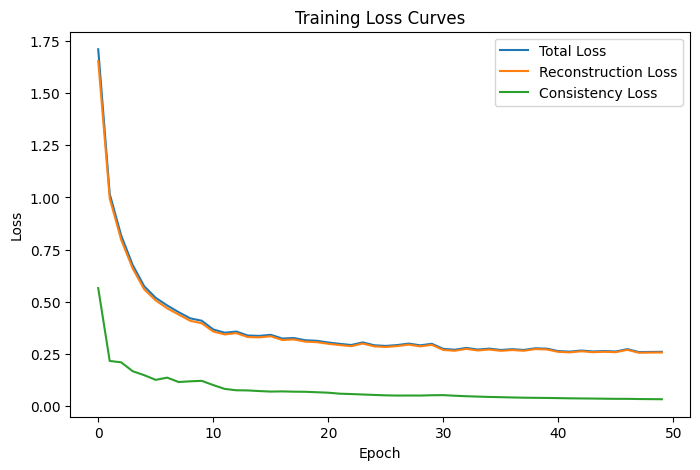

In [78]:
# =========================================
# Plot Training Curves
# =========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Total Loss")
plt.plot(rec_losses, label="Reconstruction Loss")
plt.plot(cons_losses, label="Consistency Loss")

plt.legend()
plt.title("Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [79]:
# =========================================
# Analyze Fusion Weights After Training
# =========================================

model.eval()

all_weights = []

with torch.no_grad():

    for batch in train_loader:

        v1,v2,v3,v4,_ = batch

        v1=v1.to(device)
        v2=v2.to(device)
        v3=v3.to(device)
        v4=v4.to(device)

        z1,z2,z3,z4 = model.encoder(v1,v2,v3,v4)

        weights = model.fusion(z1,z2,z3,z4)

        all_weights.append(weights.cpu())

all_weights = torch.cat(all_weights)

inspect_fusion_weights(all_weights)

Average Fusion Weights:
View1: 0.2666030824184418
View2: 0.2507542669773102
View3: 0.23739978671073914
View4: 0.2452428638935089


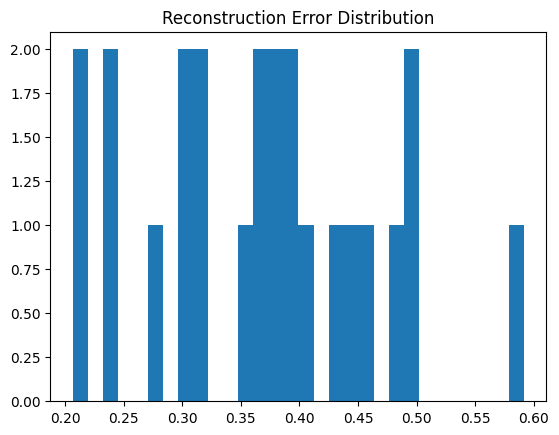

In [80]:
# =========================================
# Reconstruction Error Distribution
# =========================================

model.eval()

errors = []

with torch.no_grad():

    for batch in test_loader:

        v1,v2,v3,v4,_ = batch

        v1=v1.to(device)
        v2=v2.to(device)
        v3=v3.to(device)
        v4=v4.to(device)

        z1,z2,z3,z4,weights,zf,x1_hat,x2_hat,x3_hat,x4_hat = model(v1,v2,v3,v4)

        rec_loss,_ = reconstruction_loss(v1,v2,v3,v4,x1_hat,x2_hat,x3_hat,x4_hat)

        errors.append(rec_loss.item())

plt.hist(errors, bins=30)

plt.title("Reconstruction Error Distribution")

plt.show()

In [81]:
# =========================================
# Save Model
# =========================================

MODEL_PATH = os.path.join(BASE_DIR, "models", "meta_fusion_model.pt")

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/multiview_meta_fusion/models/meta_fusion_model.pt


In [82]:
# =========================================
# Stage 8 — Score Estimation
# Extract Latent Features for Downstream Tasks
# =========================================

def extract_latent_features(loader):

    model.eval()

    latent_features = []
    labels_list = []

    with torch.no_grad():

        for batch in loader:

            v1, v2, v3, v4, labels = batch

            v1 = v1.to(device)
            v2 = v2.to(device)
            v3 = v3.to(device)
            v4 = v4.to(device)

            z1, z2, z3, z4, weights, zf, *_ = model(v1, v2, v3, v4)

            latent_features.append(zf.cpu())
            labels_list.append(labels)

    latent_features = torch.cat(latent_features).numpy()
    labels_list = torch.cat(labels_list).numpy()

    return latent_features, labels_list

In [83]:
# =========================================
# Generate Latent Dataset
# =========================================

Z_train, y_train_latent = extract_latent_features(train_loader)
Z_test, y_test_latent = extract_latent_features(test_loader)

print("Latent Train Shape:", Z_train.shape)
print("Latent Test Shape:", Z_test.shape)

Latent Train Shape: (7352, 64)
Latent Test Shape: (2947, 64)


In [84]:
# =========================================
# Decision Layer — Classifier
# =========================================

from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

classifier.fit(Z_train, y_train_latent)

print("Classifier trained.")

Classifier trained.


In [86]:
# =========================================
# Classification Predictions
# =========================================

y_pred = classifier.predict(Z_test)

print("Predictions generated.")

Predictions generated.


In [87]:
# =========================================
# Evaluation Metrics
# =========================================

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test_latent, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test_latent, y_pred))

Accuracy: 0.8965049202578894

Classification Report:

              precision    recall  f1-score   support

           1       0.89      0.93      0.91       496
           2       0.90      0.94      0.92       471
           3       0.90      0.81      0.85       420
           4       0.85      0.82      0.83       491
           5       0.85      0.86      0.86       532
           6       0.98      1.00      0.99       537

    accuracy                           0.90      2947
   macro avg       0.90      0.89      0.89      2947
weighted avg       0.90      0.90      0.90      2947



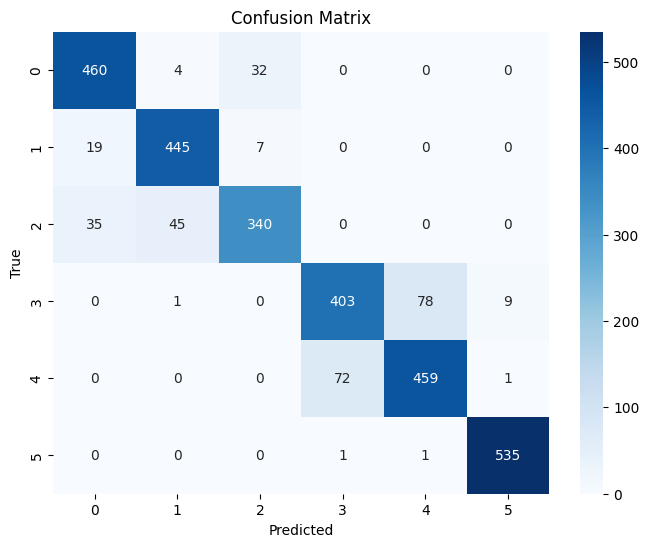

In [88]:
# =========================================
# Confusion Matrix Visualization
# =========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_latent, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

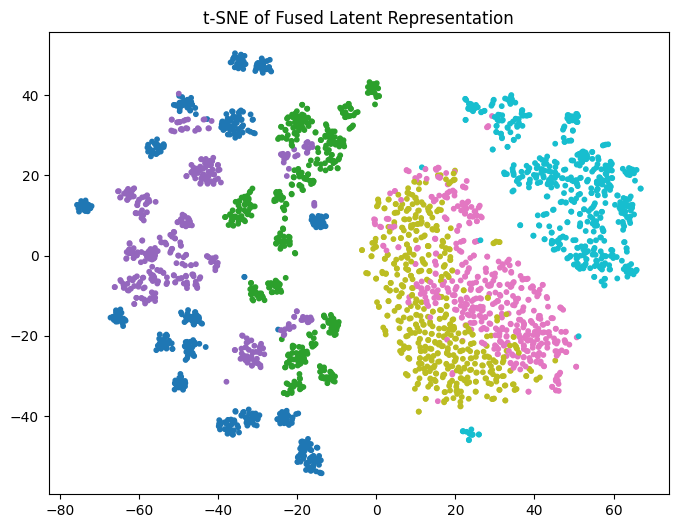

In [89]:
# =========================================
# t-SNE Visualization of Latent Space
# =========================================

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

Z_embedded = tsne.fit_transform(Z_test)

plt.figure(figsize=(8,6))

plt.scatter(
    Z_embedded[:,0],
    Z_embedded[:,1],
    c=y_test_latent,
    cmap="tab10",
    s=10
)

plt.title("t-SNE of Fused Latent Representation")

plt.show()

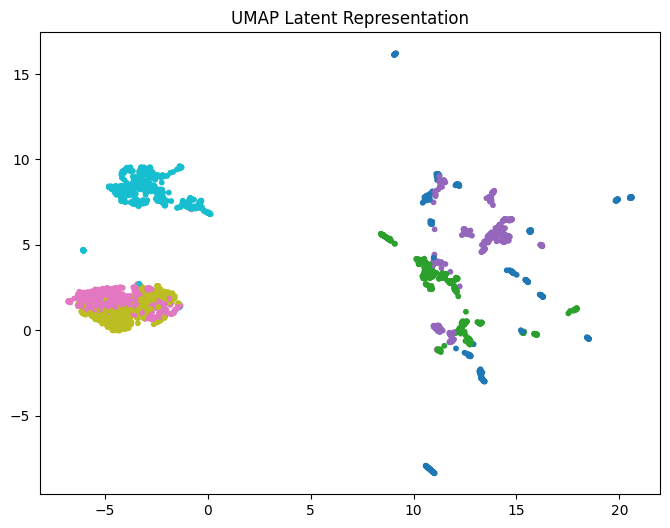

In [90]:
# =========================================
# UMAP Visualization
# =========================================

import umap

umap_model = umap.UMAP()

Z_umap = umap_model.fit_transform(Z_test)

plt.figure(figsize=(8,6))

plt.scatter(
    Z_umap[:,0],
    Z_umap[:,1],
    c=y_test_latent,
    cmap="tab10",
    s=10
)

plt.title("UMAP Latent Representation")

plt.show()

In [91]:
# =========================================
# Dimensionality Reduction Analysis
# =========================================

original_dim = X_train.shape[1]
latent_dim = CONFIG["latent_dim"]

print("Original Feature Dimension:", original_dim)
print("Latent Feature Dimension:", latent_dim)

reduction_ratio = original_dim / latent_dim

print("Compression Ratio:", reduction_ratio)

Original Feature Dimension: 561
Latent Feature Dimension: 64
Compression Ratio: 8.765625


In [92]:
# =========================================
# Stage 9 — Robustness Analysis (Ablation)
# Corrupt One View to Test Meta-Fusion
# =========================================

def corrupt_view(v, noise_std=0.5):

    noise = torch.randn_like(v) * noise_std

    v_corrupted = v + noise

    return v_corrupted

In [93]:
# =========================================
# Stage 9 — Robustness Analysis (Ablation)
# Corrupt One View to Test Meta-Fusion
# =========================================

def corrupt_view(v, noise_std=0.5):

    noise = torch.randn_like(v) * noise_std

    v_corrupted = v + noise

    return v_corrupted

In [94]:
# =========================================
# Ablation Test
# Corrupt View1 and Observe Weight Shift
# =========================================

model.eval()

fusion_weights_clean = []
fusion_weights_corrupt = []

with torch.no_grad():

    for batch in test_loader:

        v1, v2, v3, v4, _ = batch

        v1 = v1.to(device)
        v2 = v2.to(device)
        v3 = v3.to(device)
        v4 = v4.to(device)

        # Clean
        z1,z2,z3,z4 = model.encoder(v1,v2,v3,v4)
        w_clean = model.fusion(z1,z2,z3,z4)

        fusion_weights_clean.append(w_clean.cpu())

        # Corrupt view1
        v1_corrupt = corrupt_view(v1)

        z1,z2,z3,z4 = model.encoder(v1_corrupt,v2,v3,v4)
        w_corrupt = model.fusion(z1,z2,z3,z4)

        fusion_weights_corrupt.append(w_corrupt.cpu())

In [96]:
# =========================================
# Aggregate Weight Statistics
# =========================================

fusion_weights_clean = torch.cat(fusion_weights_clean)
fusion_weights_corrupt = torch.cat(fusion_weights_corrupt)

avg_clean = fusion_weights_clean.mean(dim=0)
avg_corrupt = fusion_weights_corrupt.mean(dim=0)

print("Average Weights (Clean):", avg_clean)
print("Average Weights (Corrupted):", avg_corrupt)

Average Weights (Clean): tensor([0.2665, 0.2507, 0.2376, 0.2451])
Average Weights (Corrupted): tensor([0.2666, 0.2507, 0.2377, 0.2451])


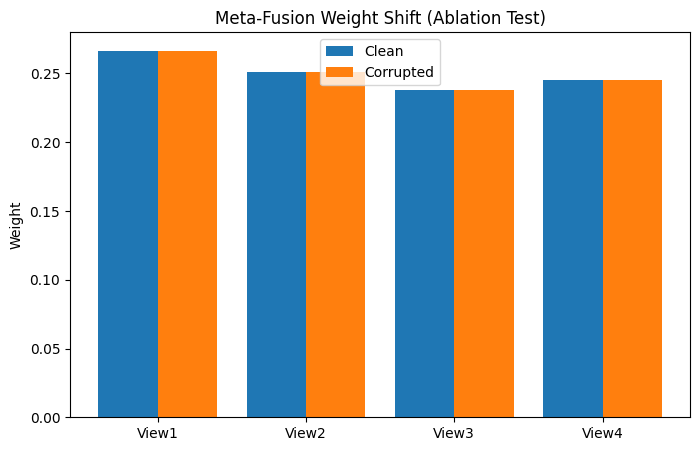

In [97]:
# =========================================
# Visualize Weight Shift
# =========================================

views = ["View1","View2","View3","View4"]

x = np.arange(len(views))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, avg_clean.numpy(), width=0.4, label="Clean")
plt.bar(x + 0.2, avg_corrupt.numpy(), width=0.4, label="Corrupted")

plt.xticks(x, views)

plt.title("Meta-Fusion Weight Shift (Ablation Test)")
plt.ylabel("Weight")
plt.legend()

plt.show()

In [98]:
# =========================================
# Reconstruction Error (Clean vs Corrupt)
# =========================================

clean_errors = []
corrupt_errors = []

with torch.no_grad():

    for batch in test_loader:

        v1,v2,v3,v4,_ = batch

        v1=v1.to(device)
        v2=v2.to(device)
        v3=v3.to(device)
        v4=v4.to(device)

        # Clean
        z1,z2,z3,z4,w,zf,x1,x2,x3,x4 = model(v1,v2,v3,v4)

        rec_loss,_ = reconstruction_loss(v1,v2,v3,v4,x1,x2,x3,x4)

        clean_errors.append(rec_loss.item())

        # Corrupt
        v1_corrupt = corrupt_view(v1)

        z1,z2,z3,z4,w,zf,x1,x2,x3,x4 = model(v1_corrupt,v2,v3,v4)

        rec_loss,_ = reconstruction_loss(v1_corrupt,v2,v3,v4,x1,x2,x3,x4)

        corrupt_errors.append(rec_loss.item())

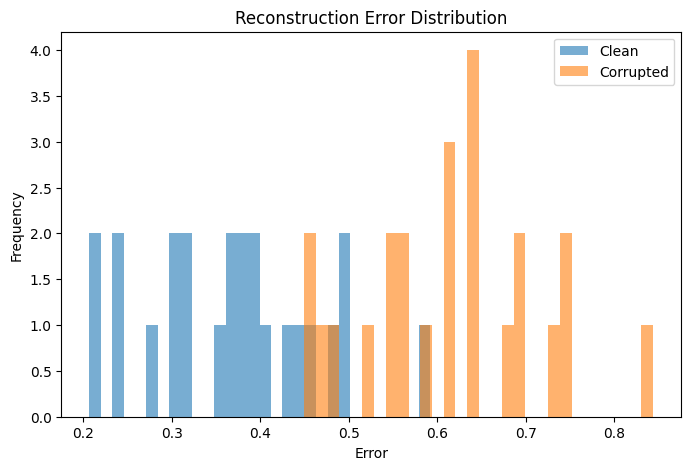

In [99]:
# =========================================
# Compare Reconstruction Errors
# =========================================

plt.figure(figsize=(8,5))

plt.hist(clean_errors, bins=30, alpha=0.6, label="Clean")
plt.hist(corrupt_errors, bins=30, alpha=0.6, label="Corrupted")

plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [100]:
# =========================================
# Robustness Score
# =========================================

clean_mean = np.mean(clean_errors)
corrupt_mean = np.mean(corrupt_errors)

robustness_ratio = corrupt_mean / clean_mean

print("Mean Reconstruction Error (Clean):", clean_mean)
print("Mean Reconstruction Error (Corrupt):", corrupt_mean)
print("Robustness Ratio:", robustness_ratio)

Mean Reconstruction Error (Clean): 0.36820730442802113
Mean Reconstruction Error (Corrupt): 0.6123277097940445
Robustness Ratio: 1.6629971823759546


In [101]:
# =========================================
# Save Ablation Results
# =========================================

results = {
    "clean_weights": avg_clean.numpy(),
    "corrupt_weights": avg_corrupt.numpy(),
    "clean_error": clean_mean,
    "corrupt_error": corrupt_mean,
    "robustness_ratio": robustness_ratio
}

RESULT_PATH = os.path.join(BASE_DIR, "results", "ablation_results.npy")

np.save(RESULT_PATH, results)

print("Ablation results saved.")

Ablation results saved.


In [102]:
# =========================================
# Stage 10 — Fusion Baseline 1
# Concatenation Fusion
# =========================================

class ConcatFusion(nn.Module):

    def __init__(self, latent_dim):

        super(ConcatFusion, self).__init__()

        self.project = nn.Linear(latent_dim * 4, latent_dim)

    def forward(self, z1, z2, z3, z4):

        concat = torch.cat([z1, z2, z3, z4], dim=1)

        z_fused = self.project(concat)

        return z_fused

In [104]:
# =========================================
# Fusion Baseline 2
# Attention-Based Fusion
# =========================================

class AttentionFusion(nn.Module):

    def __init__(self, latent_dim):

        super(AttentionFusion, self).__init__()

        self.attn = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, z1, z2, z3, z4):

        Z = torch.stack([z1,z2,z3,z4], dim=1)

        scores = self.attn(Z)

        weights = torch.softmax(scores, dim=1)

        z_fused = (weights * Z).sum(dim=1)

        return z_fused, weights.squeeze(-1)

In [105]:
# =========================================
# Fusion Baseline 3
# Transformer-Based Fusion
# =========================================

class TransformerFusion(nn.Module):

    def __init__(self, latent_dim):

        super(TransformerFusion, self).__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.pool = nn.Linear(latent_dim, latent_dim)

    def forward(self, z1, z2, z3, z4):

        Z = torch.stack([z1,z2,z3,z4], dim=1)

        Z = self.transformer(Z)

        z_fused = Z.mean(dim=1)

        z_fused = self.pool(z_fused)

        return z_fused

In [106]:
# =========================================
# Generic Baseline Model
# =========================================

class BaselineFusionModel(nn.Module):

    def __init__(self, encoder, fusion, decoder):

        super(BaselineFusionModel, self).__init__()

        self.encoder = encoder
        self.fusion = fusion
        self.decoder = decoder

    def forward(self, v1,v2,v3,v4):

        z1,z2,z3,z4 = self.encoder(v1,v2,v3,v4)

        if isinstance(self.fusion, AttentionFusion):

            zf, weights = self.fusion(z1,z2,z3,z4)

        else:

            zf = self.fusion(z1,z2,z3,z4)
            weights = None

        x1,x2,x3,x4 = self.decoder(zf)

        return z1,z2,z3,z4,weights,zf,x1,x2,x3,x4

In [107]:
# =========================================
# Initialize Fusion Strategies
# =========================================

concat_fusion = ConcatFusion(CONFIG["latent_dim"]).to(device)
attention_fusion = AttentionFusion(CONFIG["latent_dim"]).to(device)
transformer_fusion = TransformerFusion(CONFIG["latent_dim"]).to(device)

print("Baselines ready.")

Baselines ready.


In [108]:
# =========================================
# Reconstruction Evaluation Function
# =========================================

def evaluate_reconstruction(model):

    model.eval()

    errors = []

    with torch.no_grad():

        for batch in test_loader:

            v1,v2,v3,v4,_ = batch

            v1=v1.to(device)
            v2=v2.to(device)
            v3=v3.to(device)
            v4=v4.to(device)

            z1,z2,z3,z4,_,zf,x1,x2,x3,x4 = model(v1,v2,v3,v4)

            loss,_ = reconstruction_loss(v1,v2,v3,v4,x1,x2,x3,x4)

            errors.append(loss.item())

    return np.mean(errors)

In [109]:
# =========================================
# Evaluate Fusion Methods
# =========================================

concat_model = BaselineFusionModel(encoder_model, concat_fusion, decoder_model).to(device)
attention_model = BaselineFusionModel(encoder_model, attention_fusion, decoder_model).to(device)
transformer_model = BaselineFusionModel(encoder_model, transformer_fusion, decoder_model).to(device)

concat_score = evaluate_reconstruction(concat_model)
attention_score = evaluate_reconstruction(attention_model)
transformer_score = evaluate_reconstruction(transformer_model)

print("Concat Fusion Error:", concat_score)
print("Attention Fusion Error:", attention_score)
print("Transformer Fusion Error:", transformer_score)

Concat Fusion Error: 6.325255850950877
Attention Fusion Error: 0.3706822705765565
Transformer Fusion Error: 153.1572437286377


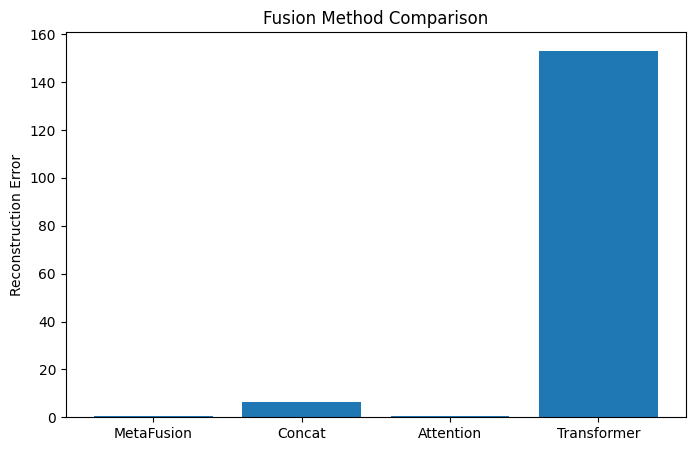

In [110]:
# =========================================
# Plot Fusion Comparison
# =========================================

methods = ["MetaFusion","Concat","Attention","Transformer"]

scores = [
    np.mean(errors),
    concat_score,
    attention_score,
    transformer_score
]

plt.figure(figsize=(8,5))

plt.bar(methods, scores)

plt.title("Fusion Method Comparison")
plt.ylabel("Reconstruction Error")

plt.show()

In [111]:
# =========================================
# Save Fusion Benchmark
# =========================================

fusion_results = {
    "MetaFusion": np.mean(errors),
    "Concat": concat_score,
    "Attention": attention_score,
    "Transformer": transformer_score
}

FUSION_PATH = os.path.join(BASE_DIR,"results","fusion_benchmark.npy")

np.save(FUSION_PATH, fusion_results)

print("Fusion benchmark saved.")

Fusion benchmark saved.


In [112]:
# =========================================
# Stage 11 — Cross Dataset Generalization
# Prepare Loader Utility
# =========================================

def prepare_multiview_dataset(dataset_name):

    X_train, y_train, X_test, y_test = DATASETS[dataset_name]()

    X_train, X_test = preprocess_features(X_train, X_test)

    v1_train, v2_train, v3_train, v4_train = create_multiview_features(dataset_name, X_train)
    v1_test, v2_test, v3_test, v4_test = create_multiview_features(dataset_name, X_test)

    v1_train, v2_train, v3_train, v4_train = normalize_views(v1_train, v2_train, v3_train, v4_train)
    v1_test, v2_test, v3_test, v4_test = normalize_views(v1_test, v2_test, v3_test, v4_test)

    train_dataset = MultiViewDataset(v1_train, v2_train, v3_train, v4_train, y_train)
    test_dataset = MultiViewDataset(v1_test, v2_test, v3_test, v4_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

    return train_loader, test_loader

In [113]:
# =========================================
# Create Loaders for All Datasets
# =========================================

dataset_loaders = {}

for dataset in DATASETS.keys():

    try:

        train_loader_d, test_loader_d = prepare_multiview_dataset(dataset)

        dataset_loaders[dataset] = {
            "train": train_loader_d,
            "test": test_loader_d
        }

        print(dataset, "prepared")

    except Exception as e:

        print(dataset, "failed:", e)

uci_har prepared


/tmp/ipykernel_486/1262454988.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


pamap2 prepared


/tmp/ipykernel_486/1580847505.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


opportunity failed: Found array with 0 sample(s) (shape=(0, 249)) while a minimum of 1 is required by SimpleImputer.
mhealth failed: invalid literal for int() with base 10: 'subject1'


In [114]:
# =========================================
# Extract Latent Representation
# =========================================

def extract_latent(loader):

    model.eval()

    Z = []
    Y = []

    with torch.no_grad():

        for batch in loader:

            v1,v2,v3,v4,labels = batch

            v1=v1.to(device)
            v2=v2.to(device)
            v3=v3.to(device)
            v4=v4.to(device)

            z1,z2,z3,z4,w,zf,_,_,_,_ = model(v1,v2,v3,v4)

            Z.append(zf.cpu())
            Y.append(labels)

    Z = torch.cat(Z).numpy()
    Y = torch.cat(Y).numpy()

    return Z, Y

In [115]:
# =========================================
# Train Classifier on Source Dataset
# =========================================

source_dataset = "uci_har"

Z_train_src, y_train_src = extract_latent(dataset_loaders[source_dataset]["train"])

classifier = RandomForestClassifier(n_estimators=200)

classifier.fit(Z_train_src, y_train_src)

print("Classifier trained on", source_dataset)

Classifier trained on uci_har


In [117]:
# =========================================
# Cross-Dataset Evaluation (Dimension Safe)
# =========================================

cross_results = {}

for dataset in dataset_loaders:

    print("\nEvaluating on:", dataset)

    loader = dataset_loaders[dataset]["test"]

    # Get sample batch to determine view dims
    sample_batch = next(iter(loader))
    v1,v2,v3,v4,_ = sample_batch

    dims = [
        v1.shape[1],
        v2.shape[1],
        v3.shape[1],
        v4.shape[1]
    ]

    # Build temporary model for dataset
    encoder_tmp = MultiViewEncoders(dims).to(device)
    decoder_tmp = MultiViewDecoders(dims).to(device)
    fusion_tmp = MetaFusionGate(CONFIG["latent_dim"]).to(device)

    temp_model = MultiViewMetaFusionModel(
        encoder_tmp,
        fusion_tmp,
        decoder_tmp
    ).to(device)

    temp_model.eval()

    Z_test = []
    Y_test = []

    with torch.no_grad():

        for batch in loader:

            v1,v2,v3,v4,labels = batch

            v1=v1.to(device)
            v2=v2.to(device)
            v3=v3.to(device)
            v4=v4.to(device)

            z1,z2,z3,z4,w,zf,_,_,_,_ = temp_model(v1,v2,v3,v4)

            Z_test.append(zf.cpu())
            Y_test.append(labels)

    Z_test = torch.cat(Z_test).numpy()
    Y_test = torch.cat(Y_test).numpy()

    y_pred = classifier.predict(Z_test)

    acc = accuracy_score(Y_test, y_pred)

    cross_results[dataset] = acc

    print(dataset, "accuracy:", acc)


Evaluating on: uci_har
uci_har accuracy: 0.19443501866304716

Evaluating on: pamap2
pamap2 accuracy: 0.09856262833675565


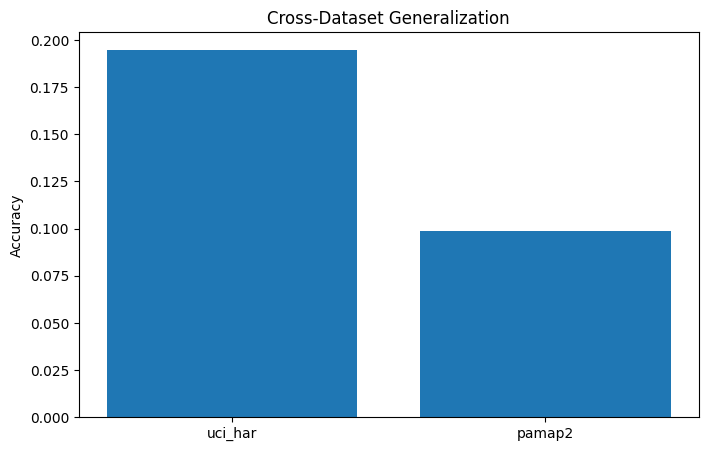

In [118]:
# =========================================
# Cross Dataset Visualization
# =========================================

datasets = list(cross_results.keys())
scores = list(cross_results.values())

plt.figure(figsize=(8,5))

plt.bar(datasets, scores)

plt.title("Cross-Dataset Generalization")
plt.ylabel("Accuracy")

plt.show()

In [119]:
# =========================================
# Latent Space Normalization
# =========================================

latent_scaler = StandardScaler()

Z_train_src = latent_scaler.fit_transform(Z_train_src)

print("Latent space normalized.")

Latent space normalized.


In [121]:
# =========================================
# Progressive Training Strategy (Safe)
# =========================================

available_datasets = list(dataset_loaders.keys())

largest_dataset = max(
    available_datasets,
    key=lambda d: len(dataset_loaders[d]["train"].dataset)
)

print("Available datasets:", available_datasets)

print("Largest dataset selected for pretraining:", largest_dataset)

print("Dataset size:",
      len(dataset_loaders[largest_dataset]["train"].dataset))

Available datasets: ['uci_har', 'pamap2']
Largest dataset selected for pretraining: pamap2
Dataset size: 27272


In [122]:
# =========================================
# Save Cross Dataset Results
# =========================================

CROSS_PATH = os.path.join(BASE_DIR,"results","cross_dataset_results.npy")

np.save(CROSS_PATH, cross_results)

print("Cross dataset evaluation saved.")

Cross dataset evaluation saved.


In [123]:
# =========================================
# Save Cross Dataset Results
# =========================================

CROSS_PATH = os.path.join(BASE_DIR,"results","cross_dataset_results.npy")

np.save(CROSS_PATH, cross_results)

print("Cross dataset evaluation saved.")

Cross dataset evaluation saved.


In [124]:
# =========================================
# Maximum Fisher Discriminant Ratio
# =========================================

def fisher_discriminant_ratio(Z, y):

    classes = np.unique(y)

    overall_mean = np.mean(Z, axis=0)

    numerator = 0
    denominator = 0

    for c in classes:

        Zc = Z[y == c]

        class_mean = np.mean(Zc, axis=0)

        numerator += len(Zc) * np.sum((class_mean - overall_mean)**2)

        denominator += np.sum((Zc - class_mean)**2)

    fdr = numerator / (denominator + 1e-8)

    return fdr

In [125]:
# =========================================
# Directional Fisher Discriminant Ratio
# =========================================

def directional_fdr(Z, y):

    classes = np.unique(y)

    between = 0
    within = 0

    for c in classes:

        Zc = Z[y == c]

        mean_vec = np.mean(Zc, axis=0)

        between += np.linalg.norm(mean_vec)**2

        within += np.sum((Zc - mean_vec)**2)

    return between / (within + 1e-8)

In [131]:
# =========================================
# Overlap Volume Estimate (Safe Version)
# =========================================

def overlap_volume(Z, y):

    from sklearn.metrics import pairwise_distances

    classes = np.unique(y)

    overlap = 0

    for i in range(len(classes)-1):

        Zi = Z[y == classes[i]]
        Zj = Z[y == classes[i+1]]

        dist = pairwise_distances(Zi, Zj)

        overlap += np.mean(dist)

    return overlap

In [127]:
# =========================================
# Maximum Individual Feature Efficiency
# =========================================

def max_feature_efficiency(Z, y):

    scores = []

    for i in range(Z.shape[1]):

        fdr = fisher_discriminant_ratio(Z[:, i:i+1], y)

        scores.append(fdr)

    return np.max(scores)

In [128]:
# =========================================
# Collective Feature Efficiency
# =========================================

def collective_feature_efficiency(Z, y):

    return fisher_discriminant_ratio(Z, y)

In [132]:
# =========================================
# Recompute Latent Representation (Safe)
# =========================================

Z_eval, y_eval = extract_latent_features(test_loader)

print("Latent shape:", Z_eval.shape)
print("Label shape:", y_eval.shape)

fdr_score = fisher_discriminant_ratio(Z_eval, y_eval)

directional_score = directional_fdr(Z_eval, y_eval)

overlap_score = overlap_volume(Z_eval, y_eval)

max_feature_score = max_feature_efficiency(Z_eval, y_eval)

collective_score = collective_feature_efficiency(Z_eval, y_eval)

print("Fisher Discriminant Ratio:", fdr_score)
print("Directional FDR:", directional_score)
print("Overlap Volume:", overlap_score)
print("Max Feature Efficiency:", max_feature_score)
print("Collective Feature Efficiency:", collective_score)

Latent shape: (2947, 64)
Label shape: (2947,)
Fisher Discriminant Ratio: 3.2104988
Directional FDR: 0.008129444
Overlap Volume: 2.966003
Max Feature Efficiency: 13.165542
Collective Feature Efficiency: 3.2104988


In [136]:
# =========================================
# Clustering Quality (Silhouette Score)
# =========================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=len(np.unique(y_eval)),
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(Z_eval)

sil_score = silhouette_score(Z_eval, clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.17304134


In [137]:
# =========================================
# Save Latent Feature Metrics
# =========================================

latent_metrics = {

    "FDR": fdr_score,
    "Directional_FDR": directional_score,
    "Overlap_Volume": overlap_score,
    "Max_Feature_Efficiency": max_feature_score,
    "Collective_Feature_Efficiency": collective_score,
    "Silhouette": sil_score

}

LATENT_PATH = os.path.join(BASE_DIR,"results","latent_metrics.npy")

np.save(LATENT_PATH, latent_metrics)

print("Latent feature metrics saved.")

Latent feature metrics saved.
